# Лабораторная работа №4

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_validate
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (BaggingClassifier, BaggingRegressor, 
                              RandomForestClassifier, RandomForestRegressor,
                              GradientBoostingClassifier, GradientBoostingRegressor,
                              AdaBoostClassifier, AdaBoostRegressor,
                              StackingClassifier, StackingRegressor)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, RocCurveDisplay, classification_report)
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier, CatBoostRegressor

import optuna

RNG_SEED = 42
np.random.seed(RNG_SEED)

### Загрузка датасетов

In [19]:
df_wine = pd.read_csv('../data/final_data_wine.csv', index_col=0)
df_wine

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,0.164343,2.283475,-2.279442,-0.749952,1.238001,-1.133138,-1.467934,1.092436,1.808131,0.263930,-0.938658,5,1
1,0.477600,3.405904,-2.279442,-0.601255,2.344580,-0.322206,-0.876417,0.751612,-0.125112,1.160428,-0.603680,5,1
2,0.477600,2.657618,-1.988649,-0.664982,2.042786,-0.901443,-1.109439,0.819769,0.249064,0.936303,-0.603680,5,1
3,3.140279,-0.335528,1.791656,-0.749952,1.187702,-0.785596,-1.001890,1.160613,-0.374562,0.413346,-0.603680,6,1
4,0.164343,2.283475,-2.279442,-0.749952,1.238001,-1.133138,-1.467934,1.092436,1.808131,0.263930,-0.938658,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4893,-0.775426,-0.772028,-0.171195,-0.813679,-0.623063,-0.380130,-0.428298,-1.177475,0.311427,-0.184319,0.568742,6,0
4894,-0.462170,-0.086099,0.337693,0.545837,-0.220671,1.531351,0.933984,0.104033,-0.436925,-0.483152,-0.771169,5,0
4895,-0.540484,-0.584956,-0.898176,-0.898649,-0.522465,-0.032588,-0.087728,-0.700317,-1.434728,-0.483152,-0.938658,6,0
4896,-1.323625,-0.273170,-0.098496,-0.919892,-1.478147,-0.611825,-0.105652,-2.012500,0.747965,-1.080818,1.908654,7,0


In [20]:
df_wine.info()

<class 'pandas.DataFrame'>
Index: 5974 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         5974 non-null   float64
 1   volatile acidity      5974 non-null   float64
 2   citric acid           5974 non-null   float64
 3   residual sugar        5974 non-null   float64
 4   chlorides             5974 non-null   float64
 5   free sulfur dioxide   5974 non-null   float64
 6   total sulfur dioxide  5974 non-null   float64
 7   density               5974 non-null   float64
 8   pH                    5974 non-null   float64
 9   sulphates             5974 non-null   float64
 10  alcohol               5974 non-null   float64
 11  quality               5974 non-null   int64  
 12  type                  5974 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 653.4 KB


In [21]:
df_diamonds = pd.read_csv("../data/final_data_diamonds.csv", index_col=0)
df_diamonds

,carat,cut,color,clarity,depth,table,price,x,y,z
0,-1.199341,4,5,1,-0.176252,-1.096824,326,-1.587838,-1.573374,-1.593630
1,-1.241582,3,5,2,-1.381332,1.591635,326,-1.641325,-1.699003,-1.766179
2,-1.199341,1,5,4,-3.437054,3.383941,327,-1.498691,-1.492612,-1.766179
3,-1.072620,3,1,3,0.461732,0.247406,334,-1.364972,-1.349036,-1.306050
4,-1.030379,1,0,1,1.099714,0.247406,335,-1.240166,-1.241354,-1.133502
...,...,...,...,...,...,...,...,...,...,...
53935,-0.164447,4,6,2,-0.672462,-0.200671,2757,0.016798,0.023908,-0.055076
53936,-0.164447,1,6,2,0.957939,-1.096824,2757,-0.036690,0.014935,0.103093
53937,-0.206688,2,6,2,0.745278,1.143559,2757,-0.063434,-0.047880,0.031198
53938,0.131237,3,2,1,-0.530687,0.247406,2757,0.373383,0.346954,0.290021


In [22]:
df_diamonds.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  int64  
 2   color    53940 non-null  int64  
 3   clarity  53940 non-null  int64  
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(4)
memory usage: 4.1 MB


### Выделеение целевого признака и предиктора, разделение на выборки

In [23]:
X_wine = df_wine.drop(columns=['type'])
y_wine = df_wine['type']
print(X_wine.shape, y_wine.shape)
print(y_wine.value_counts())

(5974, 12) (5974,)
type
0    4575
1    1399
Name: count, dtype: int64


In [24]:
X_diamonds = df_diamonds.drop(columns=["price"])
y_diamonds = df_diamonds['price']
print(X_diamonds.shape, y_diamonds.shape)
print(y_diamonds.value_counts())

(53940, 9) (53940,)
price
605     132
802     127
625     126
828     125
776     124
       ... 
2727      1
2736      1
2740      1
2747      1
2750      1
Name: count, Length: 11602, dtype: int64


### Разделение данных

In [25]:
X_temp_wine, X_test_wine, y_temp_wine, y_test_wine = train_test_split(X_wine, y_wine, test_size=0.2, stratify=y_wine, random_state=RNG_SEED)
X_train_wine, X_val_wine, y_train_wine, y_val_wine = train_test_split(X_temp_wine, y_temp_wine, test_size=0.25, stratify=y_temp_wine, random_state=RNG_SEED)

print(X_train_wine.shape, X_val_wine.shape, X_test_wine.shape)
print(y_train_wine.shape, X_val_wine.shape, y_test_wine.shape)


(3584, 12) (1195, 12) (1195, 12)
(3584,) (1195, 12) (1195,)


In [26]:
X_temp_diamonds, X_test_diamonds, y_temp_diamonds, y_test_diamonds = train_test_split(X_diamonds, y_diamonds, test_size=0.2, random_state=RNG_SEED)
X_train_diamonds, X_val_diamonds, y_train_diamonds, y_val_diamonds = train_test_split(X_temp_diamonds, y_temp_diamonds, test_size=0.25, random_state=RNG_SEED)

print(X_train_diamonds.shape, X_val_diamonds.shape, X_test_diamonds.shape)
print(y_train_diamonds.shape, X_val_diamonds.shape, y_test_diamonds.shape)

(32364, 9) (10788, 9) (10788, 9)
(32364,) (10788, 9) (10788,)


### Балансировка

In [27]:
y_train_wine.value_counts()

type
0    2745
1     839
Name: count, dtype: int64

In [28]:
oversample = SMOTE()

X_train_bal_wine, y_train_bal_wine = oversample.fit_resample(X_train_wine, y_train_wine)
y_train_bal_wine.value_counts()

type
0    2745
1    2745
Name: count, dtype: int64

### Вспомогательные функции

In [42]:
def calculate_metrics_cls(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1': f1_score(y_true, y_pred, average='weighted')
    }

def calculate_metrics_reg(y_true, y_pred):
    return {
        'MSE': mean_squared_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }


def print_cv_results_table(cv_scores, model_name="Model"):
    metric_mapping = {
        'F1': 'test_f1_weighted',
        'Accuracy': 'test_accuracy',
        'Precision': 'test_precision_weighted',
        'Recall': 'test_recall_weighted'
    }
    
    data = {'Fold': list(range(len(cv_scores['test_accuracy'])))}
    for col_name, key in metric_mapping.items():
        data[col_name] = cv_scores[key]
        
    df = pd.DataFrame(data).set_index('Fold')
    
    df.loc['Mean'] = df.mean()
    df.loc['Std'] = df.std()
    
    print(f"\nРезультаты 10-Fold CV для {model_name}")
    display(df.style.format('{:.4f}').apply(
        lambda row: ['background-color: #FFFF00' if row.name == 'Mean' else '' for _ in row], 
        axis=1
    ))

def fmt(val, metric_name):
    prec = 2 if metric_name == 'F1' else 4
    return f"{val:.{prec}f}"


def plot_and_extract_rules(model, X_train, feature_names, max_depth=3):
    plt.figure(figsize=(30, 6))
    plot_tree(model, feature_names=feature_names, class_names=['White', 'Red'], 
              filled=True, max_depth=max_depth, fontsize=10)
    plt.title("Decision Tree Visualization")
    plt.show()
    
    from sklearn.tree import _tree
    def tree_to_rules(tree, feature_names):
        tree_ = tree.tree_
        feature_name = [feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined!" for i in tree_.feature]
        paths = []
        def recurse(node, path):
            if tree_.feature[node] != _tree.TREE_UNDEFINED:
                name = feature_name[node]
                threshold = tree_.threshold[node]
                recurse(tree_.children_left[node], path + [f"{name} <= {threshold:.2f}"])
                recurse(tree_.children_right[node], path + [f"{name} > {threshold:.2f}"])
            else:
                paths.append(" AND ".join(path))
        recurse(0, [])
        return paths
    
    print("Decision Rules:")
    for rule in tree_to_rules(model, feature_names)[:5]:
        print(f" {rule}")

In [73]:
cls_models = {
    'DecisionTree': DecisionTreeClassifier(random_state=RNG_SEED),
    'Bagging': BaggingClassifier(random_state=RNG_SEED),
    'RandomForest': RandomForestClassifier(random_state=RNG_SEED),
    'GradientBoosting': GradientBoostingClassifier(random_state=RNG_SEED),
    'AdaBoost': AdaBoostClassifier(random_state=RNG_SEED),
    'XGBoost': xgb.XGBClassifier(random_state=RNG_SEED, eval_metric='logloss'),
    'LightGBM': lgb.LGBMClassifier(random_state=RNG_SEED, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=RNG_SEED, verbose=0),
}

reg_models = {
    'DecisionTree': DecisionTreeRegressor(random_state=RNG_SEED),
    'Bagging': BaggingRegressor(random_state=RNG_SEED),
    'RandomForest': RandomForestRegressor(random_state=RNG_SEED),
    'GradientBoosting': GradientBoostingRegressor(random_state=RNG_SEED),
    'AdaBoost': AdaBoostRegressor(random_state=RNG_SEED),
    'XGBoost': xgb.XGBRegressor(random_state=RNG_SEED),
    'LightGBM': lgb.LGBMRegressor(random_state=RNG_SEED, verbose=-1),
    'CatBoost': CatBoostRegressor(random_state=RNG_SEED, verbose=0),
}

cv_wine = StratifiedKFold(n_splits=5, shuffle=True, random_state=RNG_SEED)
cv_diamonds = KFold(n_splits=5, shuffle=True, random_state=RNG_SEED)

cls_results_wine = []
reg_results_diamonds = []

In [72]:
def train_evaluate_loop(models_dict, X_train, y_train, X_val, y_val, X_test, y_test, cv, task_type, metrics_func, res_list, is_cls=True):
    for name, model in models_dict.items():
        print(f"\n{task_type}: {name}")
        
        cv_scores = cross_validate(model, X_val, y_val, cv=cv, 
                                   scoring='f1_weighted' if is_cls else 'neg_root_mean_squared_error', n_jobs=-1)
        
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)
        
        metrics_train = metrics_func(y_train, y_pred_train)
        metrics_test = metrics_func(y_test, y_pred_test)
        
        row = {'Algorithm': name, 'Task': task_type}
        for k in metrics_train.keys():
            row[('Train Data', k)] = fmt(metrics_train[k], k)
            row[('Test Data', k)] = fmt(metrics_test[k], k)
        res_list.append(row)

        if is_cls:
            print("    Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))
            RocCurveDisplay.from_estimator(model, X_test, y_test)
            plt.title(f'ROC Curve - {name}')
            plt.show()
        
        print(f"    Train Metrics: { {k: fmt(metrics_test[k], k) for k in metrics_train} }")
        print(f"    Test Metrics: { {k: fmt(metrics_test[k], k) for k in metrics_test} }")
        
        if name == 'DecisionTree' and task_type == 'Classification':
            plot_and_extract_rules(model, X_train, X_train.columns)


Classification: DecisionTree
    Confusion Matrix:
 [[906   9]
 [  6 274]]


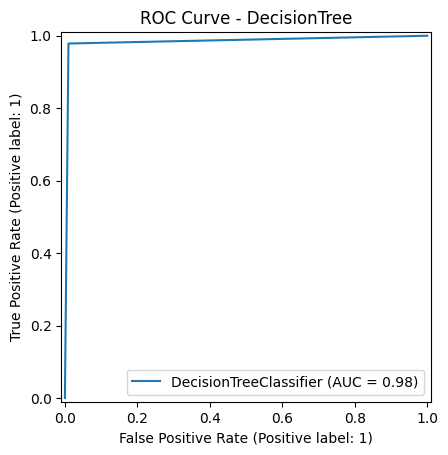

    Train Metrics: {'Accuracy': '0.9874', 'Precision': '0.9875', 'Recall': '0.9874', 'F1': '0.99'}
    Test Metrics: {'Accuracy': '0.9874', 'Precision': '0.9875', 'Recall': '0.9874', 'F1': '0.99'}


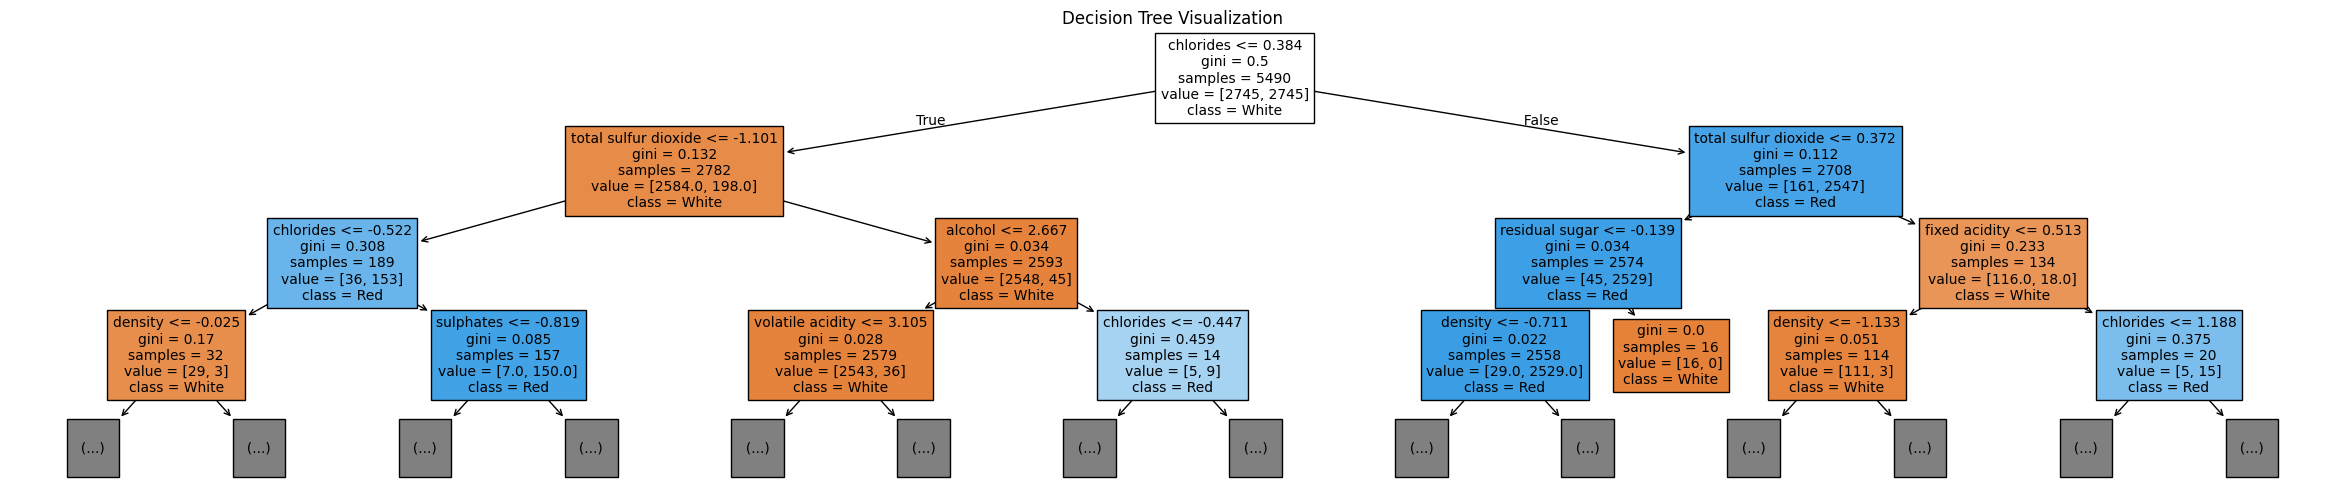

Decision Rules:
 chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides <= -0.52 AND density <= -0.03
 chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides <= -0.52 AND density > -0.03
 chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides > -0.52 AND sulphates <= -0.82 AND chlorides <= 0.06
 chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides > -0.52 AND sulphates <= -0.82 AND chlorides > 0.06
 chlorides <= 0.38 AND total sulfur dioxide <= -1.10 AND chlorides > -0.52 AND sulphates > -0.82

Classification: Bagging


In [ ]:
train_evaluate_loop(cls_models, X_train_bal_wine, y_train_bal_wine, X_val_wine, y_val_wine, X_test_wine, y_test_wine, cv_wine, 'Classification', calculate_metrics_cls, cls_results_wine, is_cls=True)

In [ ]:
train_evaluate_loop(reg_models, X_train_diamonds, y_train_diamonds, X_val_diamonds, y_val_diamonds, X_test_diamonds, y_test_diamonds, cv_diamonds, 'Regression', calculate_metrics_reg, reg_results_diamonds, is_cls=False)


Regression: DecisionTree
    Train Metrics: {'MSE': '574116.9167', 'RMSE': '757.7050', 'MAE': '369.5366', 'R2': '0.9639'}
    Test Metrics: {'MSE': '574116.9167', 'RMSE': '757.7050', 'MAE': '369.5366', 'R2': '0.9639'}

Regression: Bagging
    Train Metrics: {'MSE': '330476.1430', 'RMSE': '574.8705', 'MAE': '287.7034', 'R2': '0.9792'}
    Test Metrics: {'MSE': '330476.1430', 'RMSE': '574.8705', 'MAE': '287.7034', 'R2': '0.9792'}

Regression: RandomForest
    Train Metrics: {'MSE': '303800.0374', 'RMSE': '551.1806', 'MAE': '273.1247', 'R2': '0.9809'}
    Test Metrics: {'MSE': '303800.0374', 'RMSE': '551.1806', 'MAE': '273.1247', 'R2': '0.9809'}

Regression: GradientBoosting
    Train Metrics: {'MSE': '366731.1416', 'RMSE': '605.5833', 'MAE': '337.9039', 'R2': '0.9769'}
    Test Metrics: {'MSE': '366731.1416', 'RMSE': '605.5833', 'MAE': '337.9039', 'R2': '0.9769'}

Regression: AdaBoost
    Train Metrics: {'MSE': '1280571.2541', 'RMSE': '1131.6233', 'MAE': '855.3261', 'R2': '0.9194'}
    